# ACIT4610 Assignment 2 · Multi-objective CFLP with NSGA-II and SPEA2
Select the project's `.venv` as the kernel and use Restart & Run All. All settings are in `config.yaml`.

## Step 0. Check the Python environment
Shows which Python the notebook uses. The path should end in `.venv\Scripts\python.exe` inside the project folder.

In [1]:
# A path outside the project means the kernel is not using the project's .venv
import sys
print(sys.executable)

C:\Users\jesse\Documents\DocsBackup\OsloMetH2026\More-Courses\ACIT4610-Evolu-AI\Prog\ACIT4610-A2-Group2\.venv\Scripts\python.exe


## Step 1. Check the configuration
Loads `config.yaml` and prints every setting.

In [2]:
# Every constant the other modules use is listed here
%run -m src.util.fetch_config

Loaded C:\Users\jesse\Documents\DocsBackup\OsloMetH2026\More-Courses\ACIT4610-Evolu-AI\Prog\ACIT4610-A2-Group2\config.yaml

PROJECT_ROOT = C:\Users\jesse\Documents\DocsBackup\OsloMetH2026\More-Courses\ACIT4610-Evolu-AI\Prog\ACIT4610-A2-Group2
CONFIG_PATH = C:\Users\jesse\Documents\DocsBackup\OsloMetH2026\More-Courses\ACIT4610-Evolu-AI\Prog\ACIT4610-A2-Group2\config.yaml
DATA_DIR = C:\Users\jesse\Documents\DocsBackup\OsloMetH2026\More-Courses\ACIT4610-Evolu-AI\Prog\ACIT4610-A2-Group2\data\orlib
CHECKSUM_FILE = SHA256SUMS
RESULTS_DIR = C:\Users\jesse\Documents\DocsBackup\OsloMetH2026\More-Courses\ACIT4610-Evolu-AI\Prog\ACIT4610-A2-Group2\results
RAW_DIR = C:\Users\jesse\Documents\DocsBackup\OsloMetH2026\More-Courses\ACIT4610-Evolu-AI\Prog\ACIT4610-A2-Group2\results\raw
TABLES_DIR = C:\Users\jesse\Documents\DocsBackup\OsloMetH2026\More-Courses\ACIT4610-Evolu-AI\Prog\ACIT4610-A2-Group2\results\tables
FIGURES_DIR = C:\Users\jesse\Documents\DocsBackup\OsloMetH2026\More-Courses\ACIT4610-Evolu

## Step 2. Check the data
Verifies that the OR-Library files are unmodified and checks whether each instance can have a feasible solution.

In [3]:
# Every instance is checked for feasibility before any algorithm runs
%run -m src.data_loader

All data files in C:\Users\jesse\Documents\DocsBackup\OsloMetH2026\More-Courses\ACIT4610-Evolu-AI\Prog\ACIT4610-A2-Group2\data\orlib match SHA256SUMS.

small_1: cap61  (16 facilities, 50 customers)
  capacity     min 15,000  max 15,000
  fixed cost   min 0  max 7,500
  demand       total 58,268  max 12,912
  OK: ready for the MOEAs

small_2: cap62  (16 facilities, 50 customers)
  capacity     min 15,000  max 15,000
  fixed cost   min 0  max 12,500
  demand       total 58,268  max 12,912
  OK: ready for the MOEAs

medium_1: cap101  (25 facilities, 50 customers)
  capacity     min 58,268  max 58,268
  fixed cost   min 0  max 7,500
  demand       total 58,268  max 12,912
  OK: ready for the MOEAs

medium_2: cap102  (25 facilities, 50 customers)
  capacity     min 58,268  max 58,268
  fixed cost   min 0  max 12,500
  demand       total 58,268  max 12,912
  OK: ready for the MOEAs

large_1: cap121  (50 facilities, 50 customers)
  capacity     min 15,000  max 15,000
  fixed cost   min 0  max

## Step 3. Run the experiments
Runs NSGA-II and SPEA2 with the same seed in each run and saves the raw results to `results/raw`.

In [4]:
# Takes about 15 to 25 minutes in total
%run -m src.run_experiments

All data files in C:\Users\jesse\Documents\DocsBackup\OsloMetH2026\More-Courses\ACIT4610-Evolu-AI\Prog\ACIT4610-A2-Group2\data\orlib match SHA256SUMS.

[small_1] cap61: 16 facilities, 50 customers
  C1 run  1/10  NSGA-II    1.8 s    9 distinct front points
  C1 run  1/10  SPEA2      1.4 s   10 distinct front points
  C1 run  2/10  NSGA-II    2.0 s    8 distinct front points
  C1 run  2/10  SPEA2      1.6 s    9 distinct front points
  C1 run  3/10  NSGA-II    2.1 s    9 distinct front points
  C1 run  3/10  SPEA2      1.9 s   10 distinct front points
  C1 run  4/10  NSGA-II    1.7 s    8 distinct front points
  C1 run  4/10  SPEA2      1.6 s   10 distinct front points
  C1 run  5/10  NSGA-II    1.7 s    9 distinct front points
  C1 run  5/10  SPEA2      1.9 s    8 distinct front points
  C1 run  6/10  NSGA-II    1.6 s   10 distinct front points
  C1 run  6/10  SPEA2      1.6 s    9 distinct front points
  C1 run  7/10  NSGA-II    1.8 s    9 distinct front points
  C1 run  7/10  SPEA2  

## Step 4. Analyse the results
Computes hypervolume, the number of non-dominated solutions, runtime and the Wilcoxon test.

In [5]:
# Tables go to results/tables and Pareto-front plots to results/figures
%run -m src.analyze_results


[small_1] cap61
  normalisation: ideal = [22,500.00, 855,327.38], nadir = [105,000.00, 1,523,768.81], reference point = [1.1, 1.1]

Results for cap61
Config  Algorithm  HV mean ± std    HV best  HV worst  #ND mean ± std  Time (s)  p (HV)  Better
------  ---------  ---------------  -------  --------  --------------  --------  ------  ------
C1      NSGA-II    1.0817 ± 0.0114  1.1055   1.0680    8.8 ± 0.6       1.88      0.9219  n.s.  
C1      SPEA2      1.0800 ± 0.0210  1.1100   1.0372    9.5 ± 0.8       1.64                    
C2      NSGA-II    1.0945 ± 0.0138  1.1170   1.0696    9.4 ± 0.8       2.46      0.6953  n.s.  
C2      SPEA2      1.0916 ± 0.0140  1.1223   1.0707    9.2 ± 1.0       2.23                    
C3      NSGA-II    1.0484 ± 0.0186  1.0756   1.0256    10.1 ± 1.1      2.27      0.5566  n.s.  
C3      SPEA2      1.0430 ± 0.0194  1.0776   1.0085    9.6 ± 1.2       1.88                    
  plot saved: C:\Users\jesse\Documents\DocsBackup\OsloMetH2026\More-Courses\ACIT4

## Step 5. Results
Shows the saved results tables and Pareto-front plots for each instance.

results_cap101.png


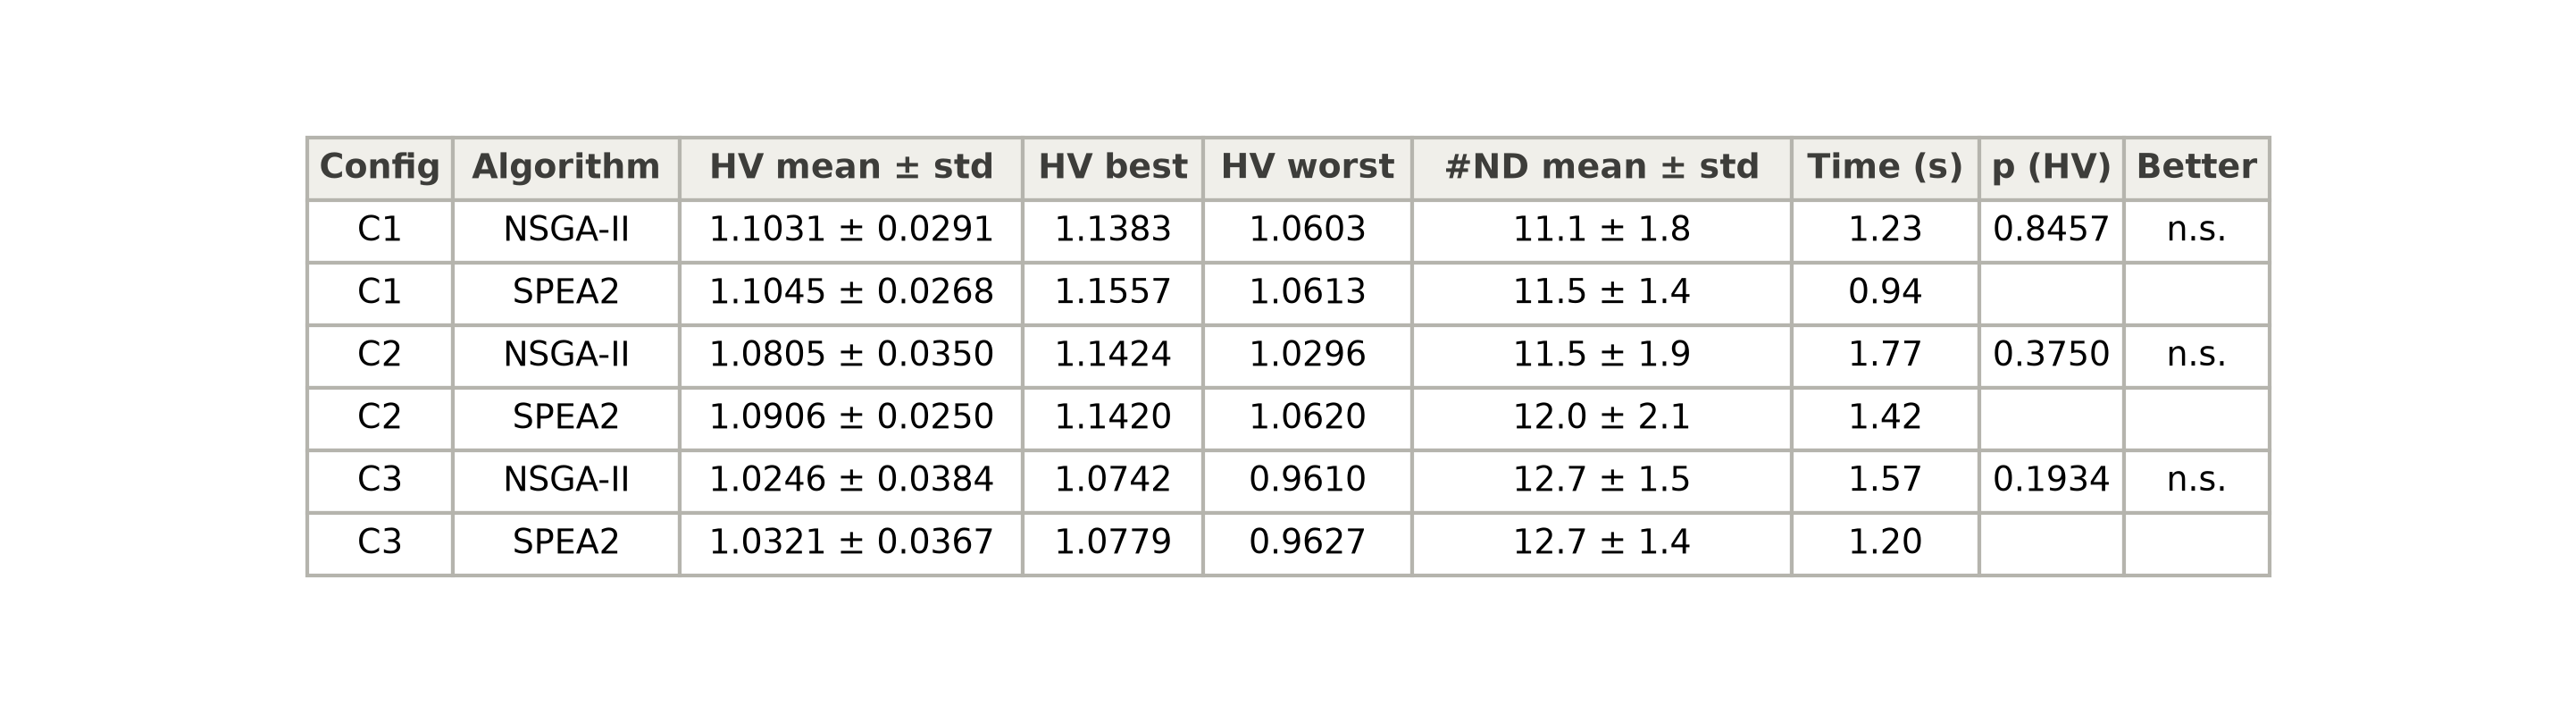

results_cap102.png


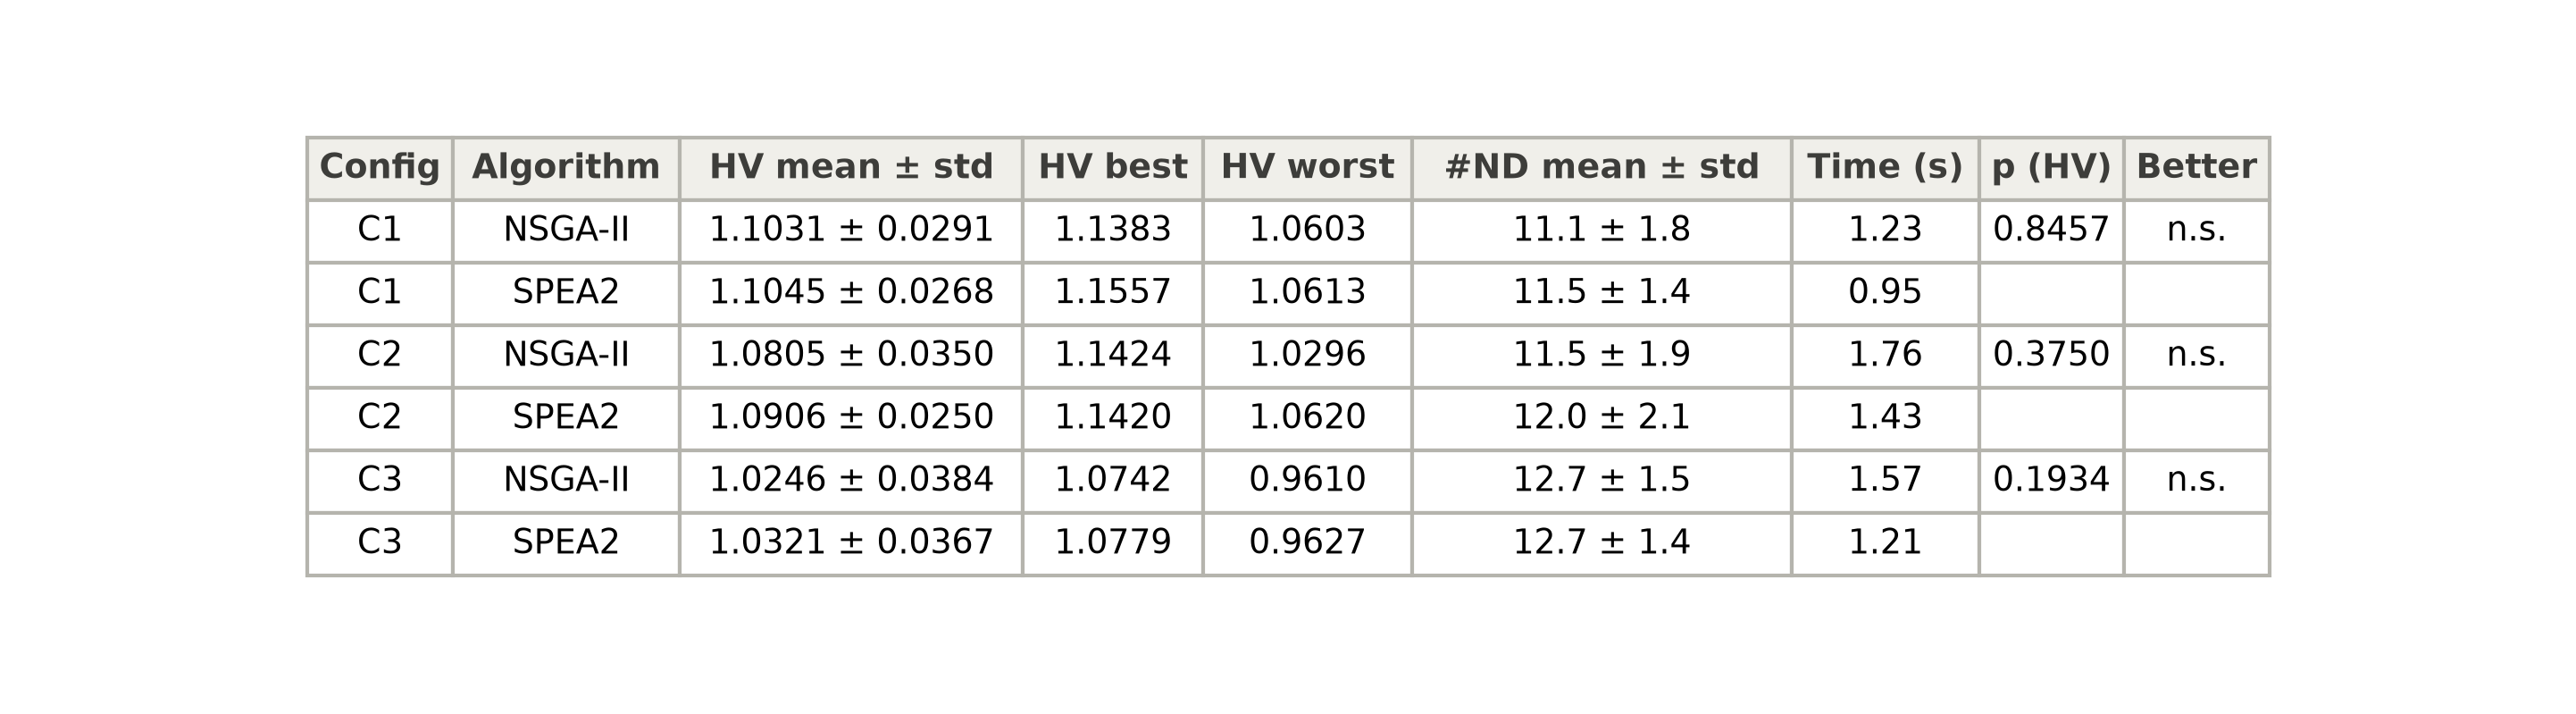

results_cap121.png


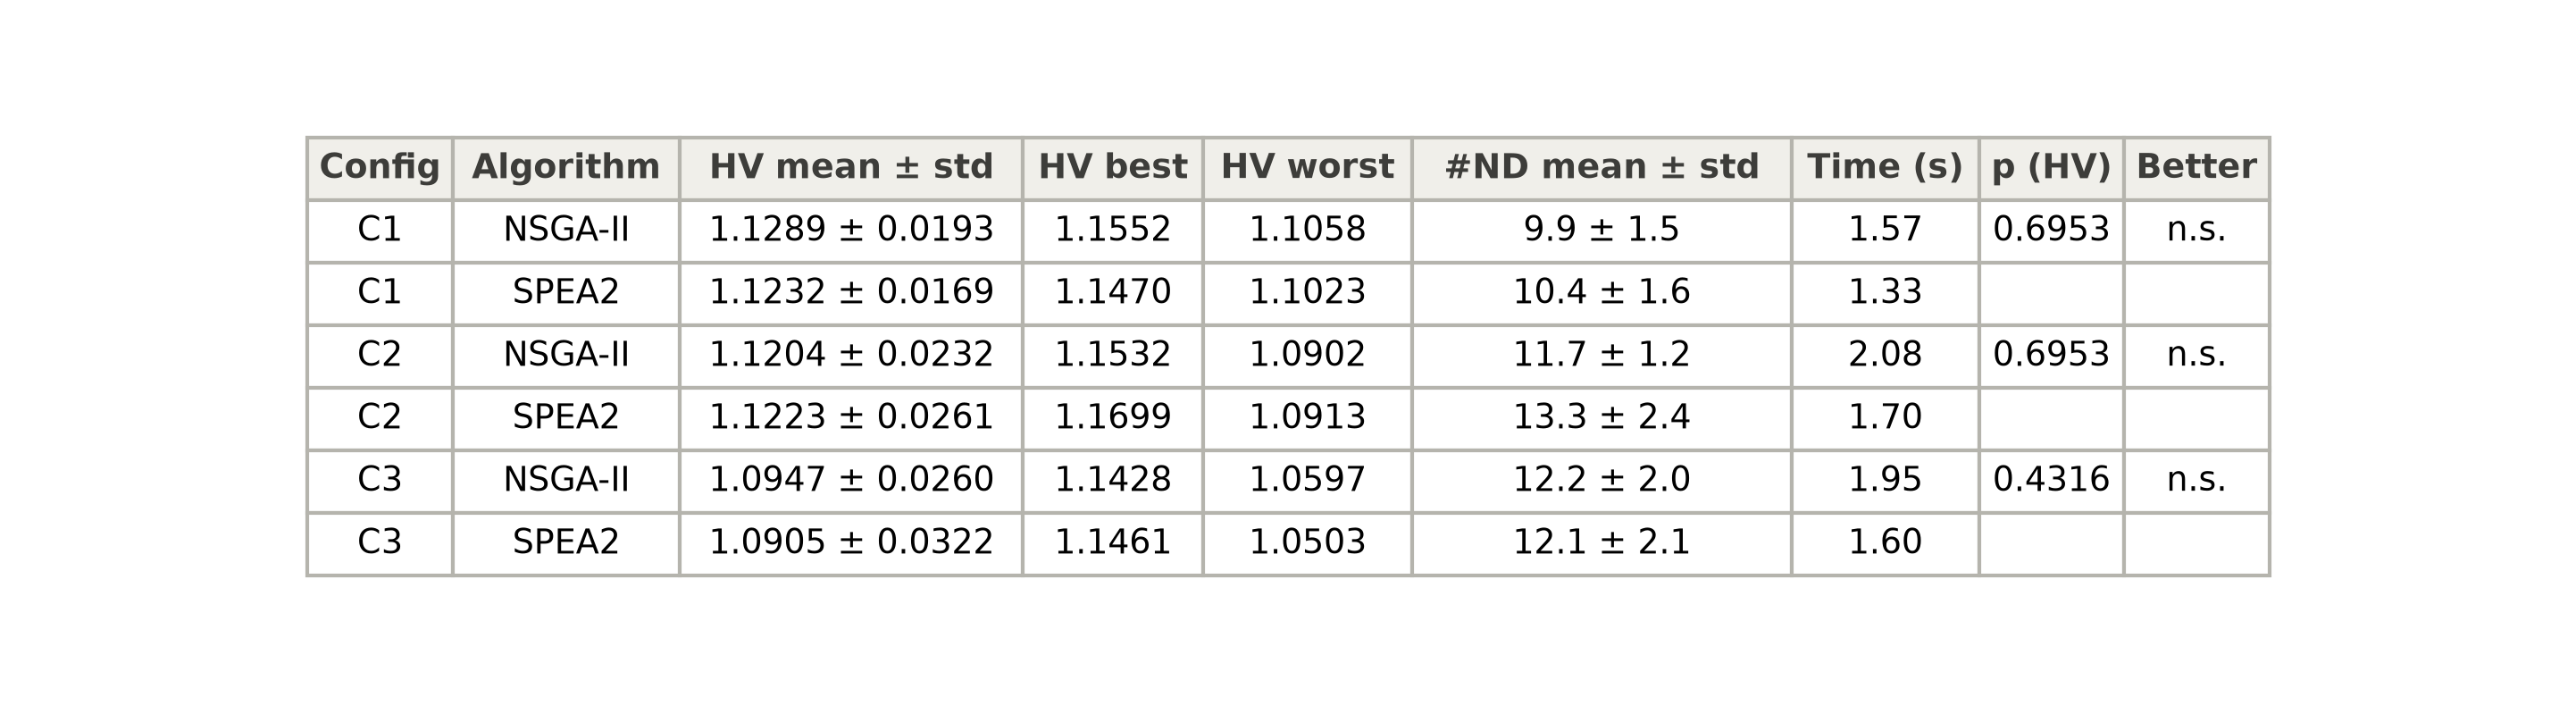

results_cap122.png


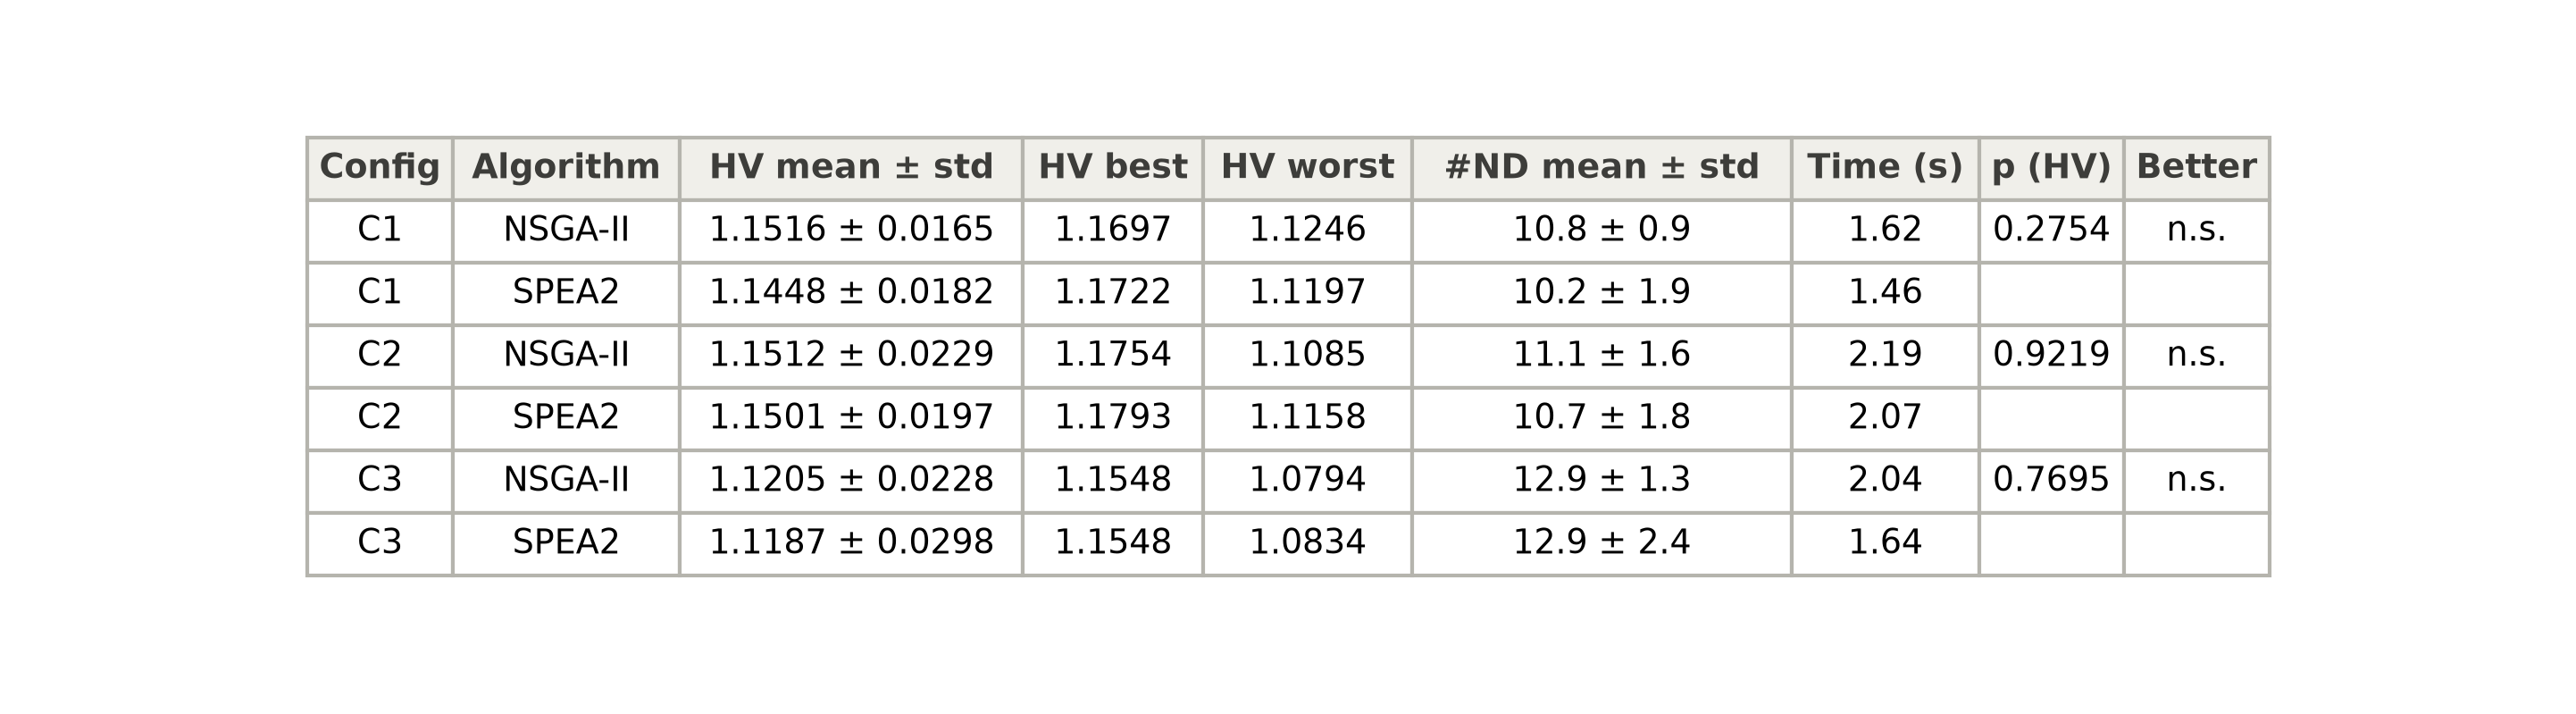

results_cap61.png


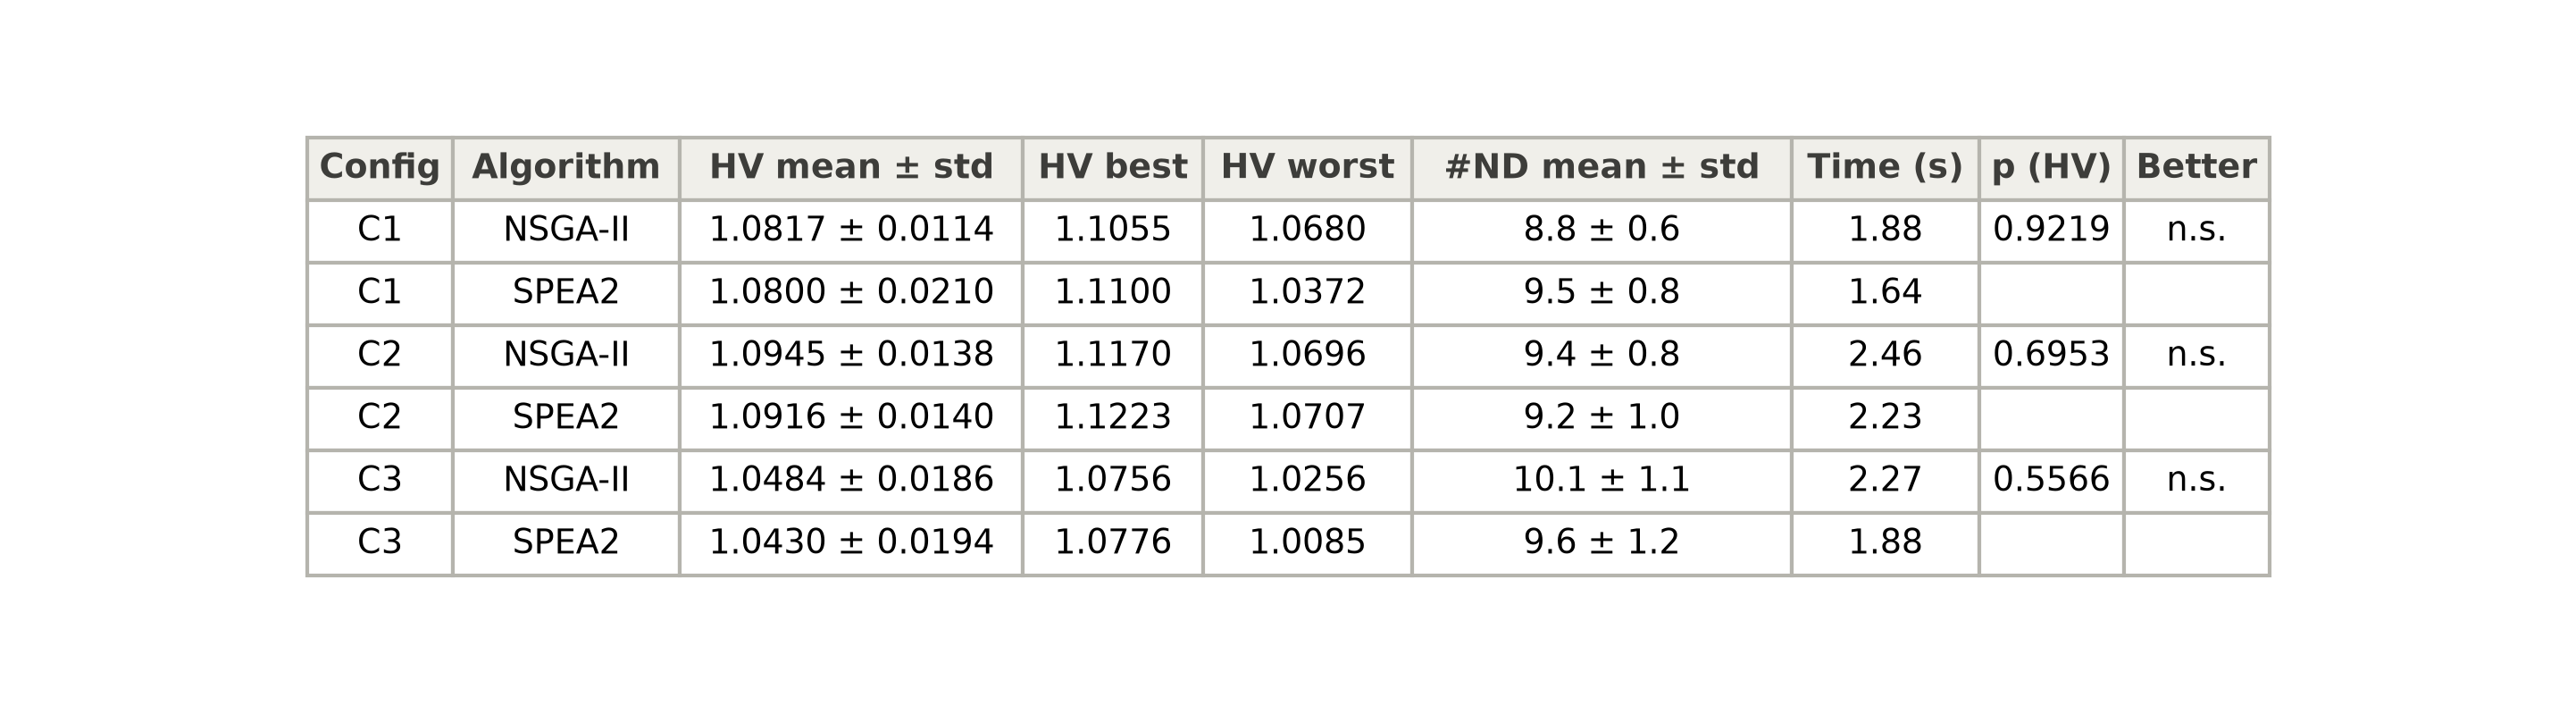

results_cap62.png


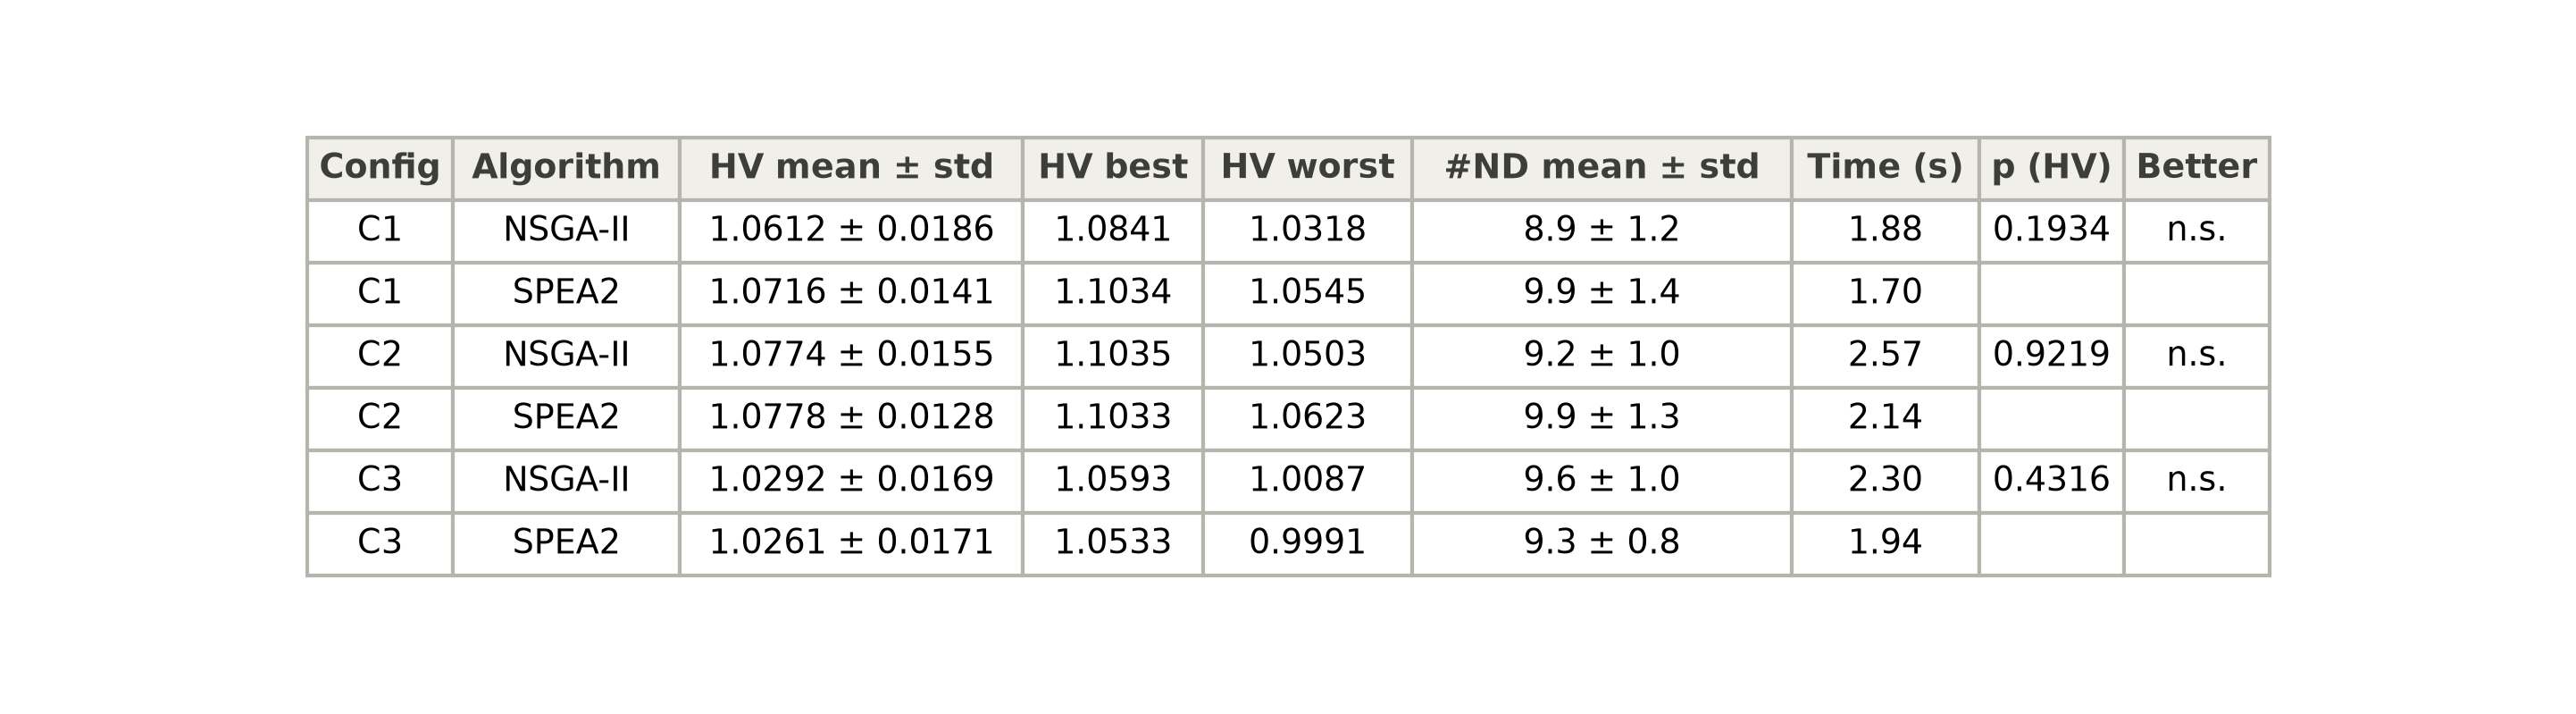

pareto_cap101.png


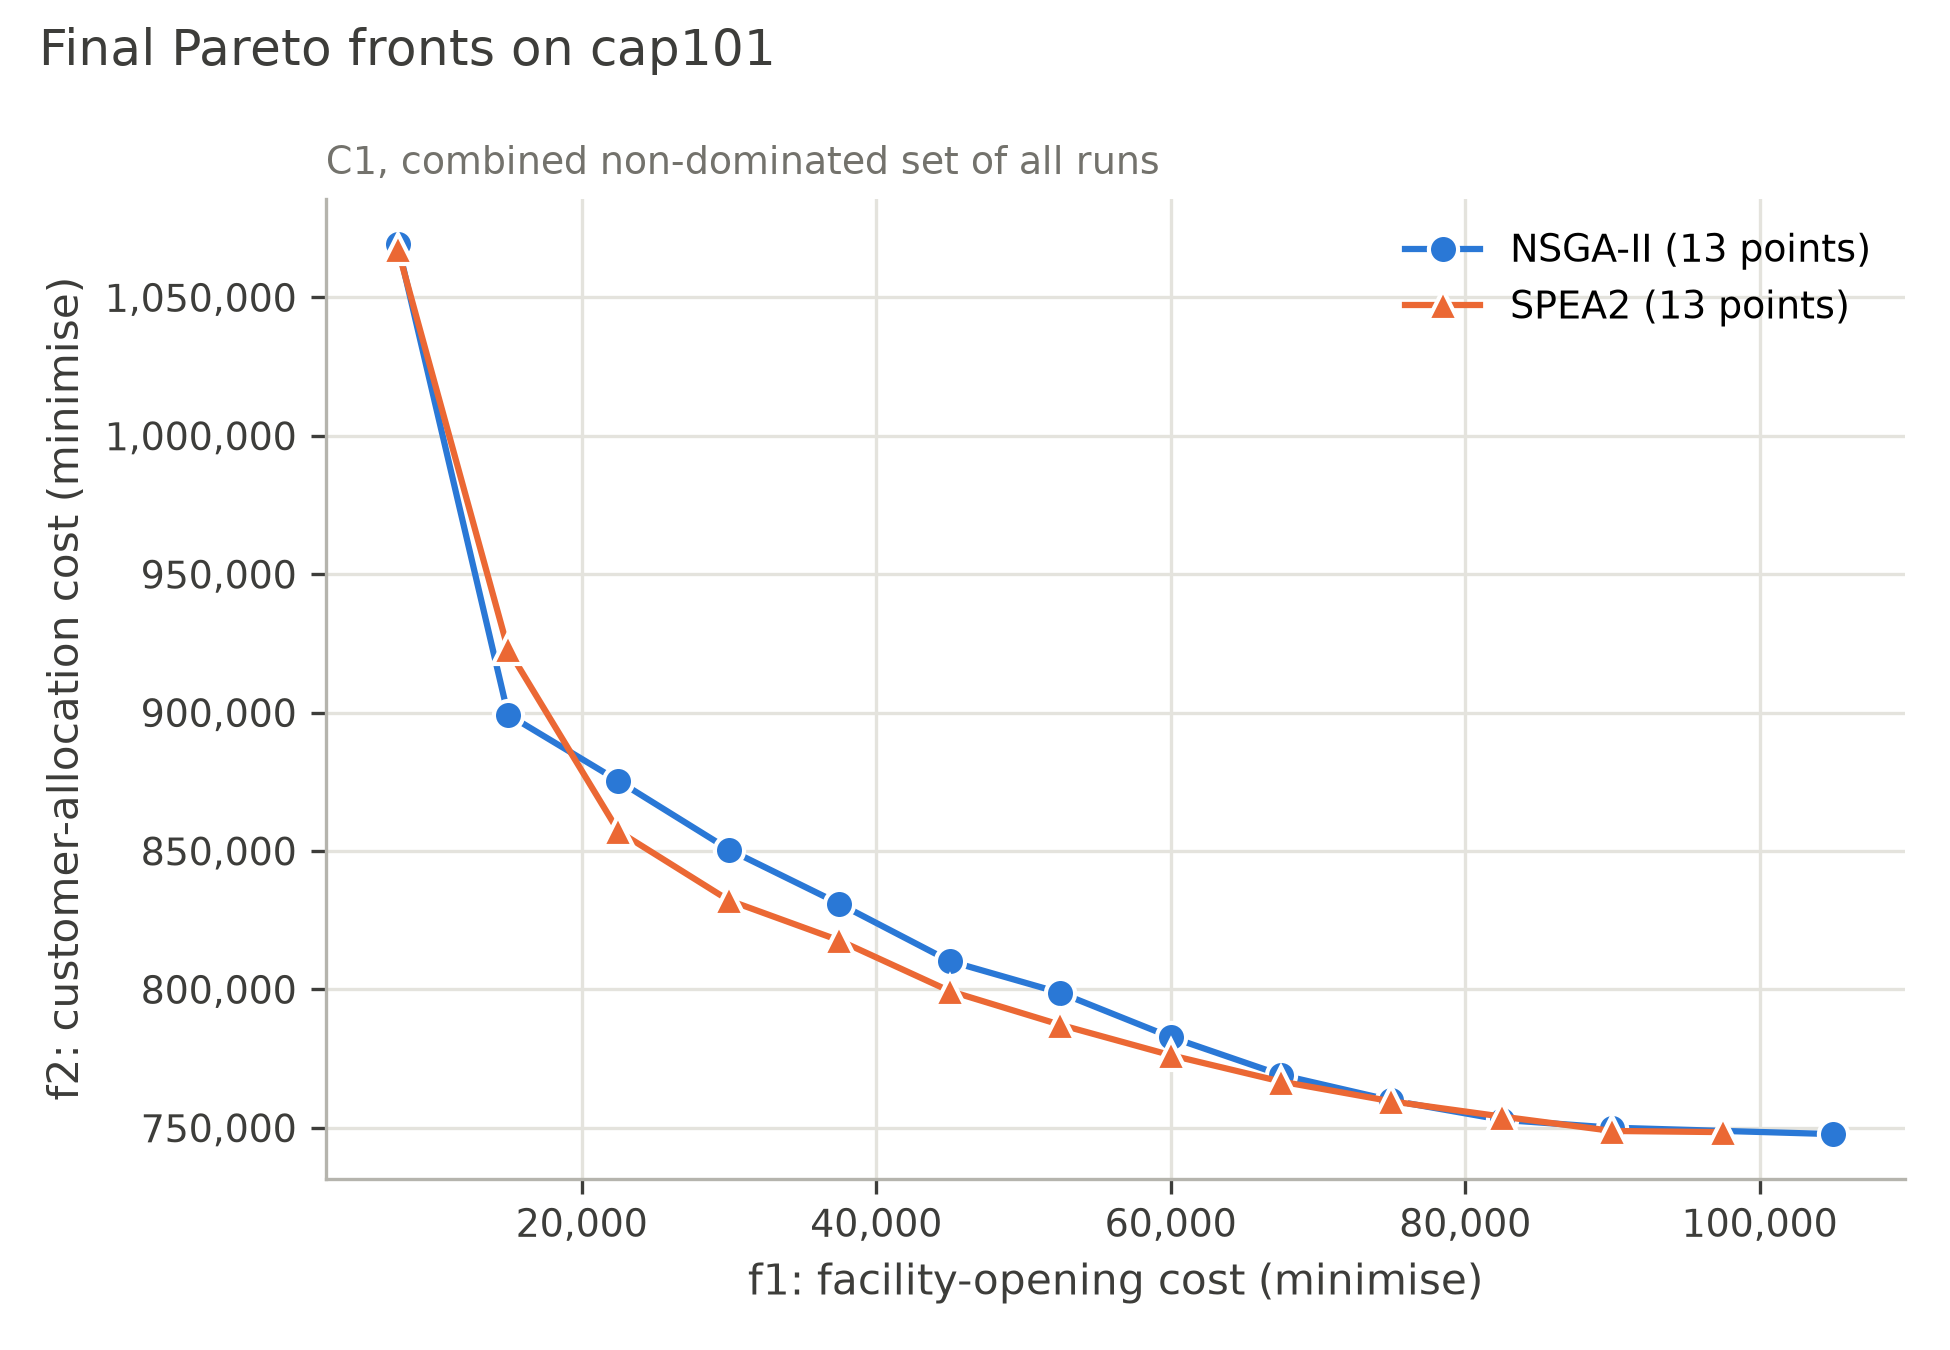

pareto_cap102.png


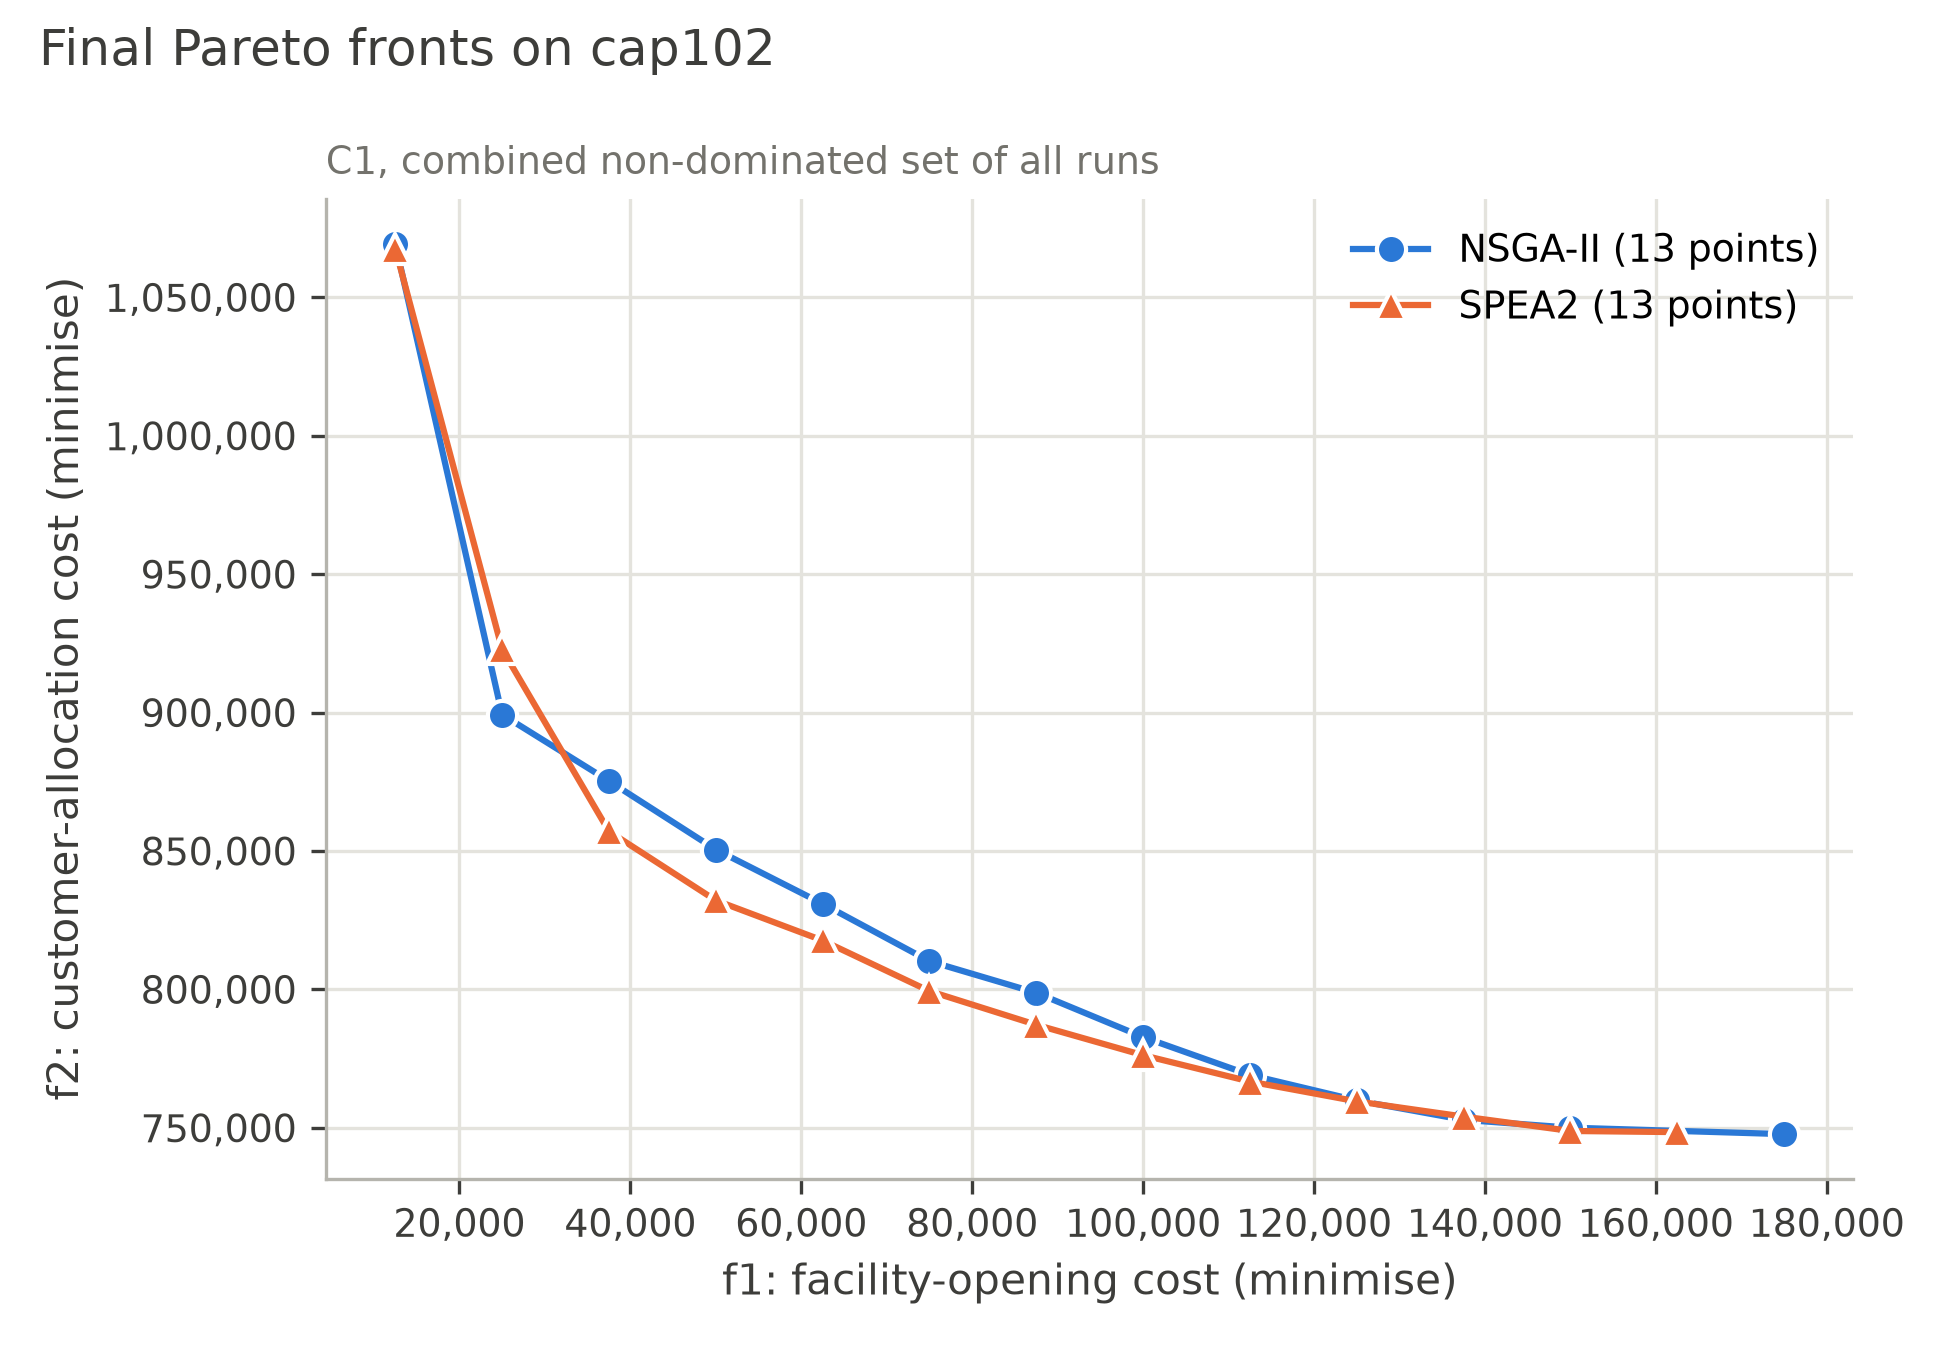

pareto_cap121.png


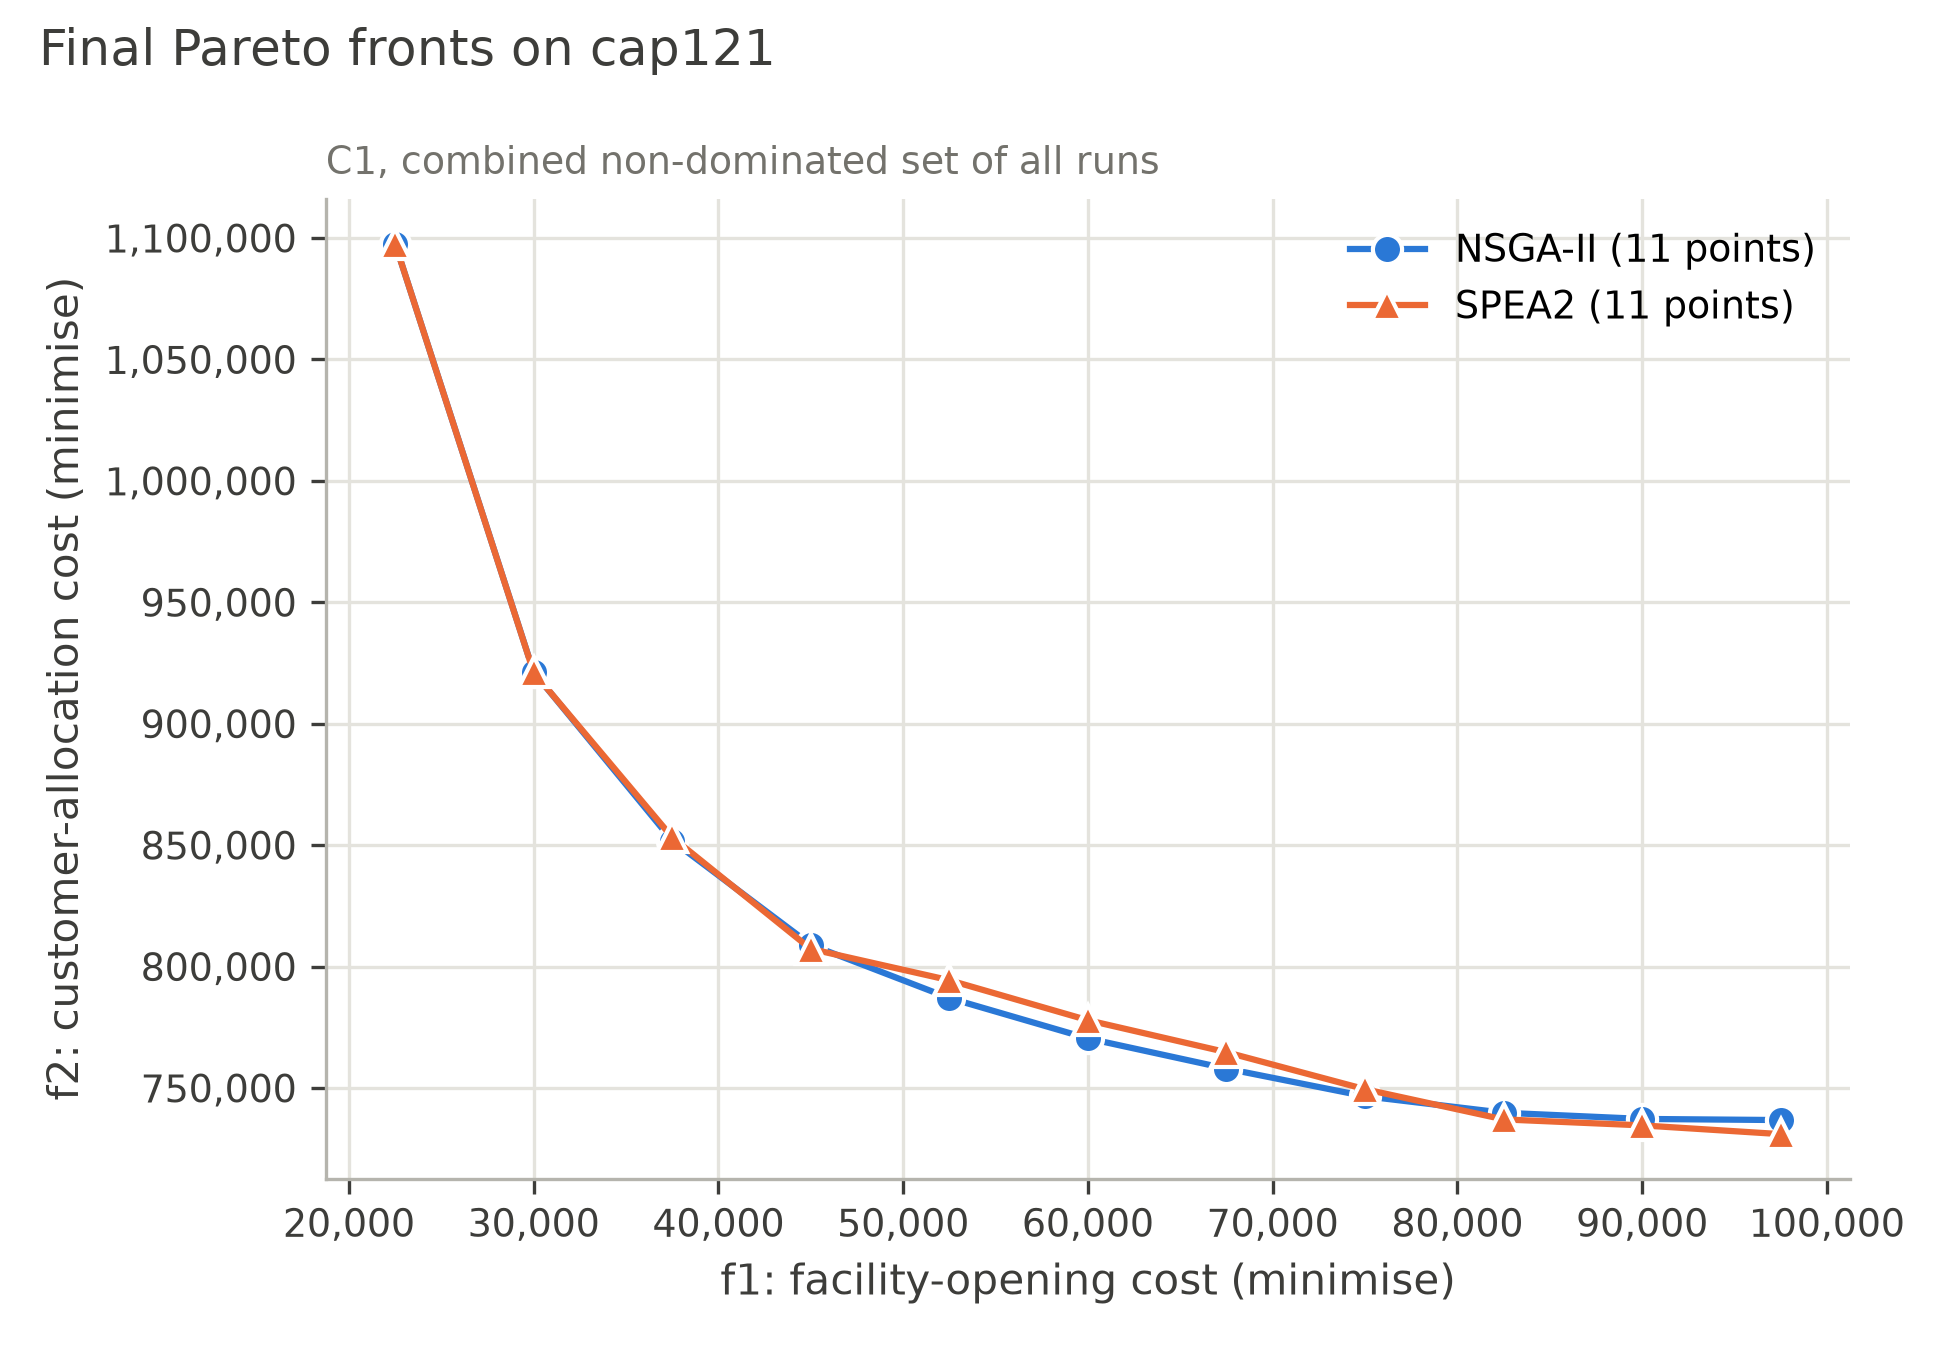

pareto_cap122.png


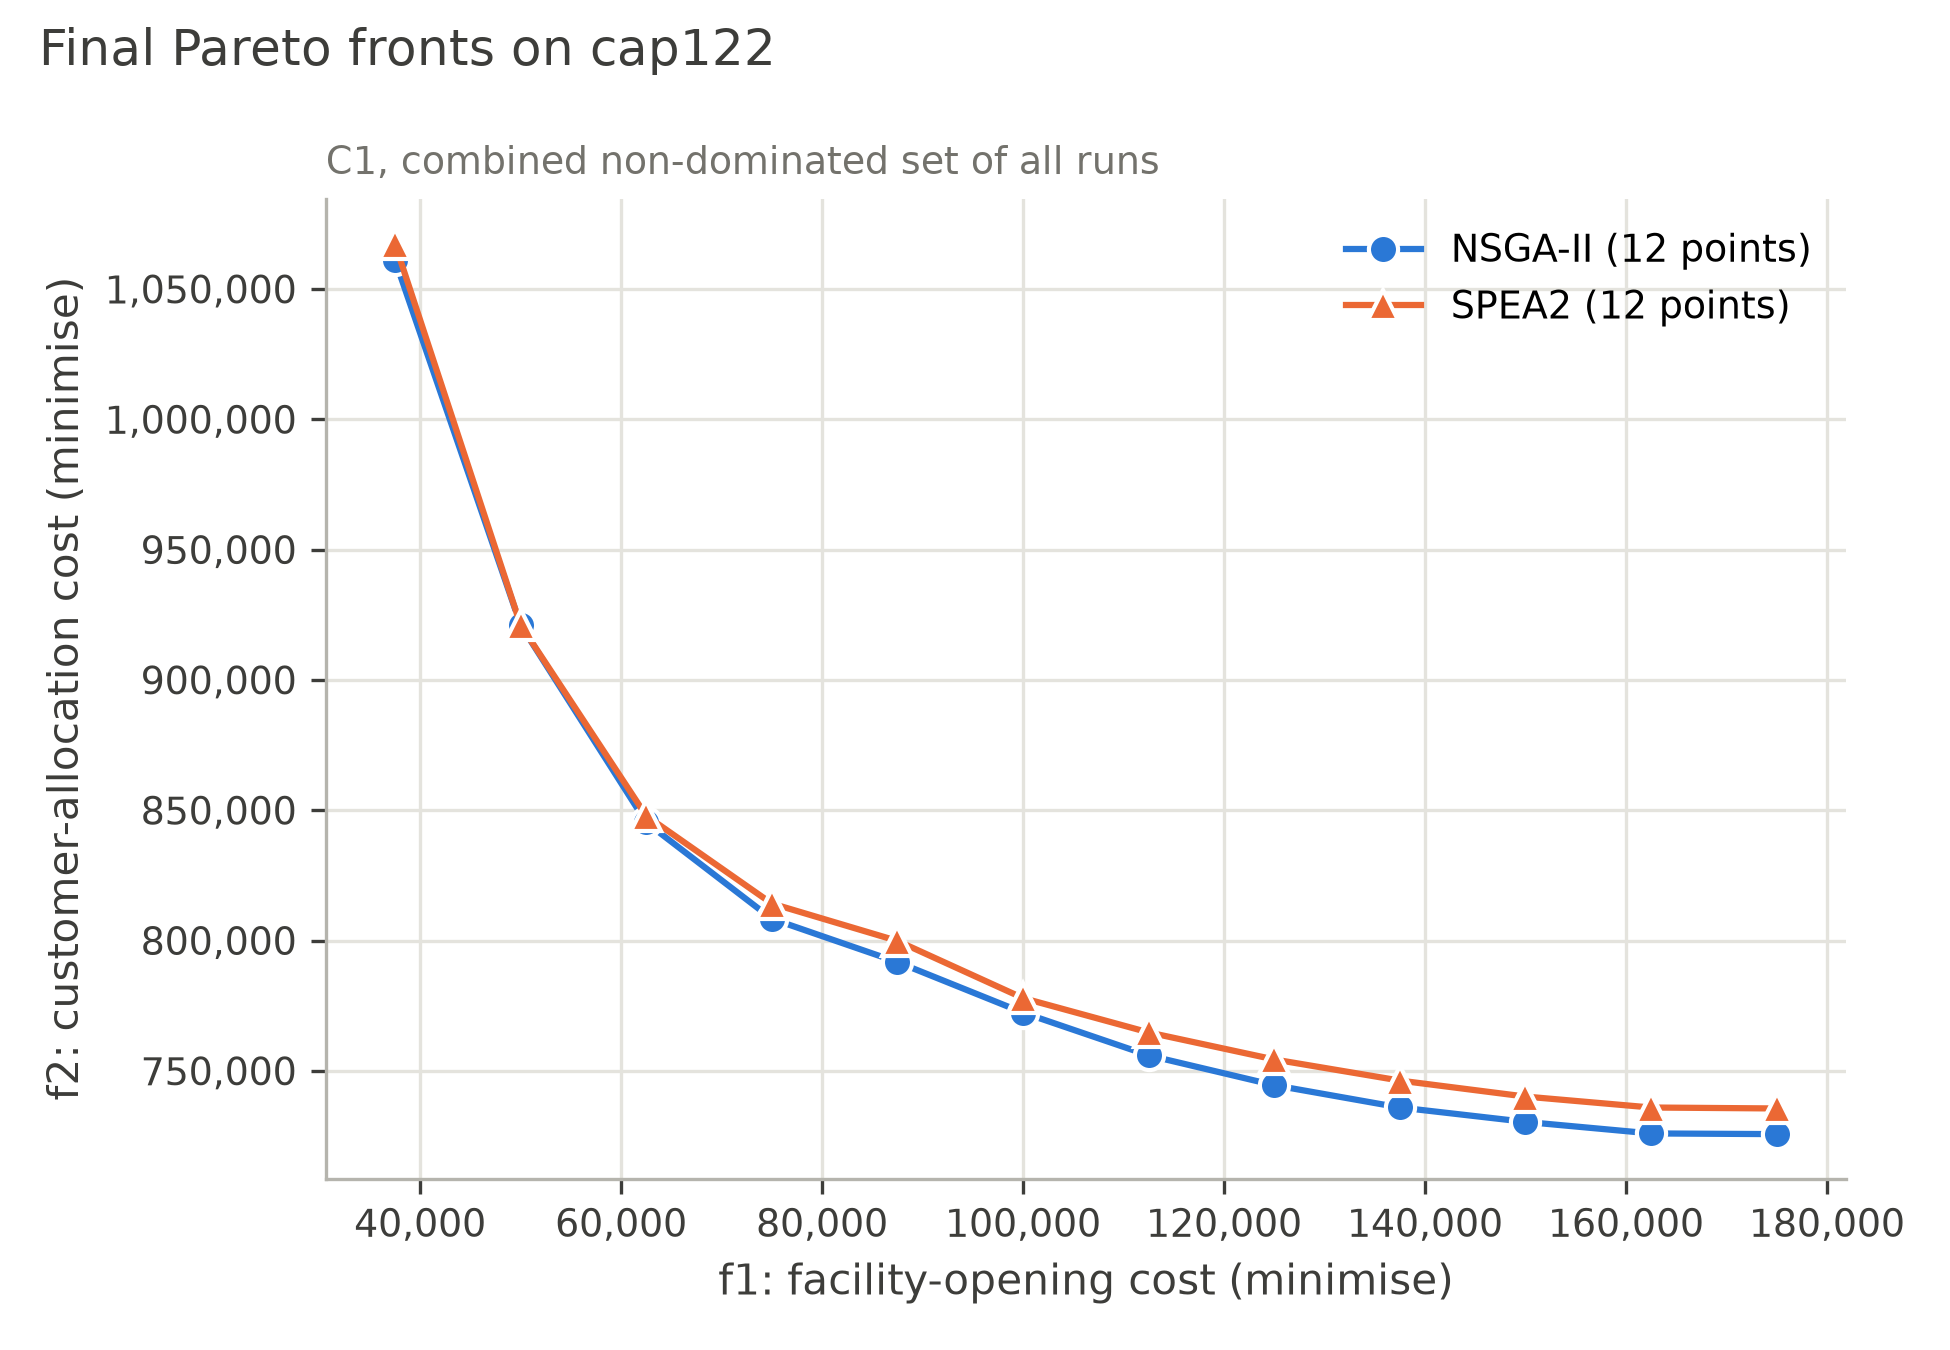

pareto_cap61.png


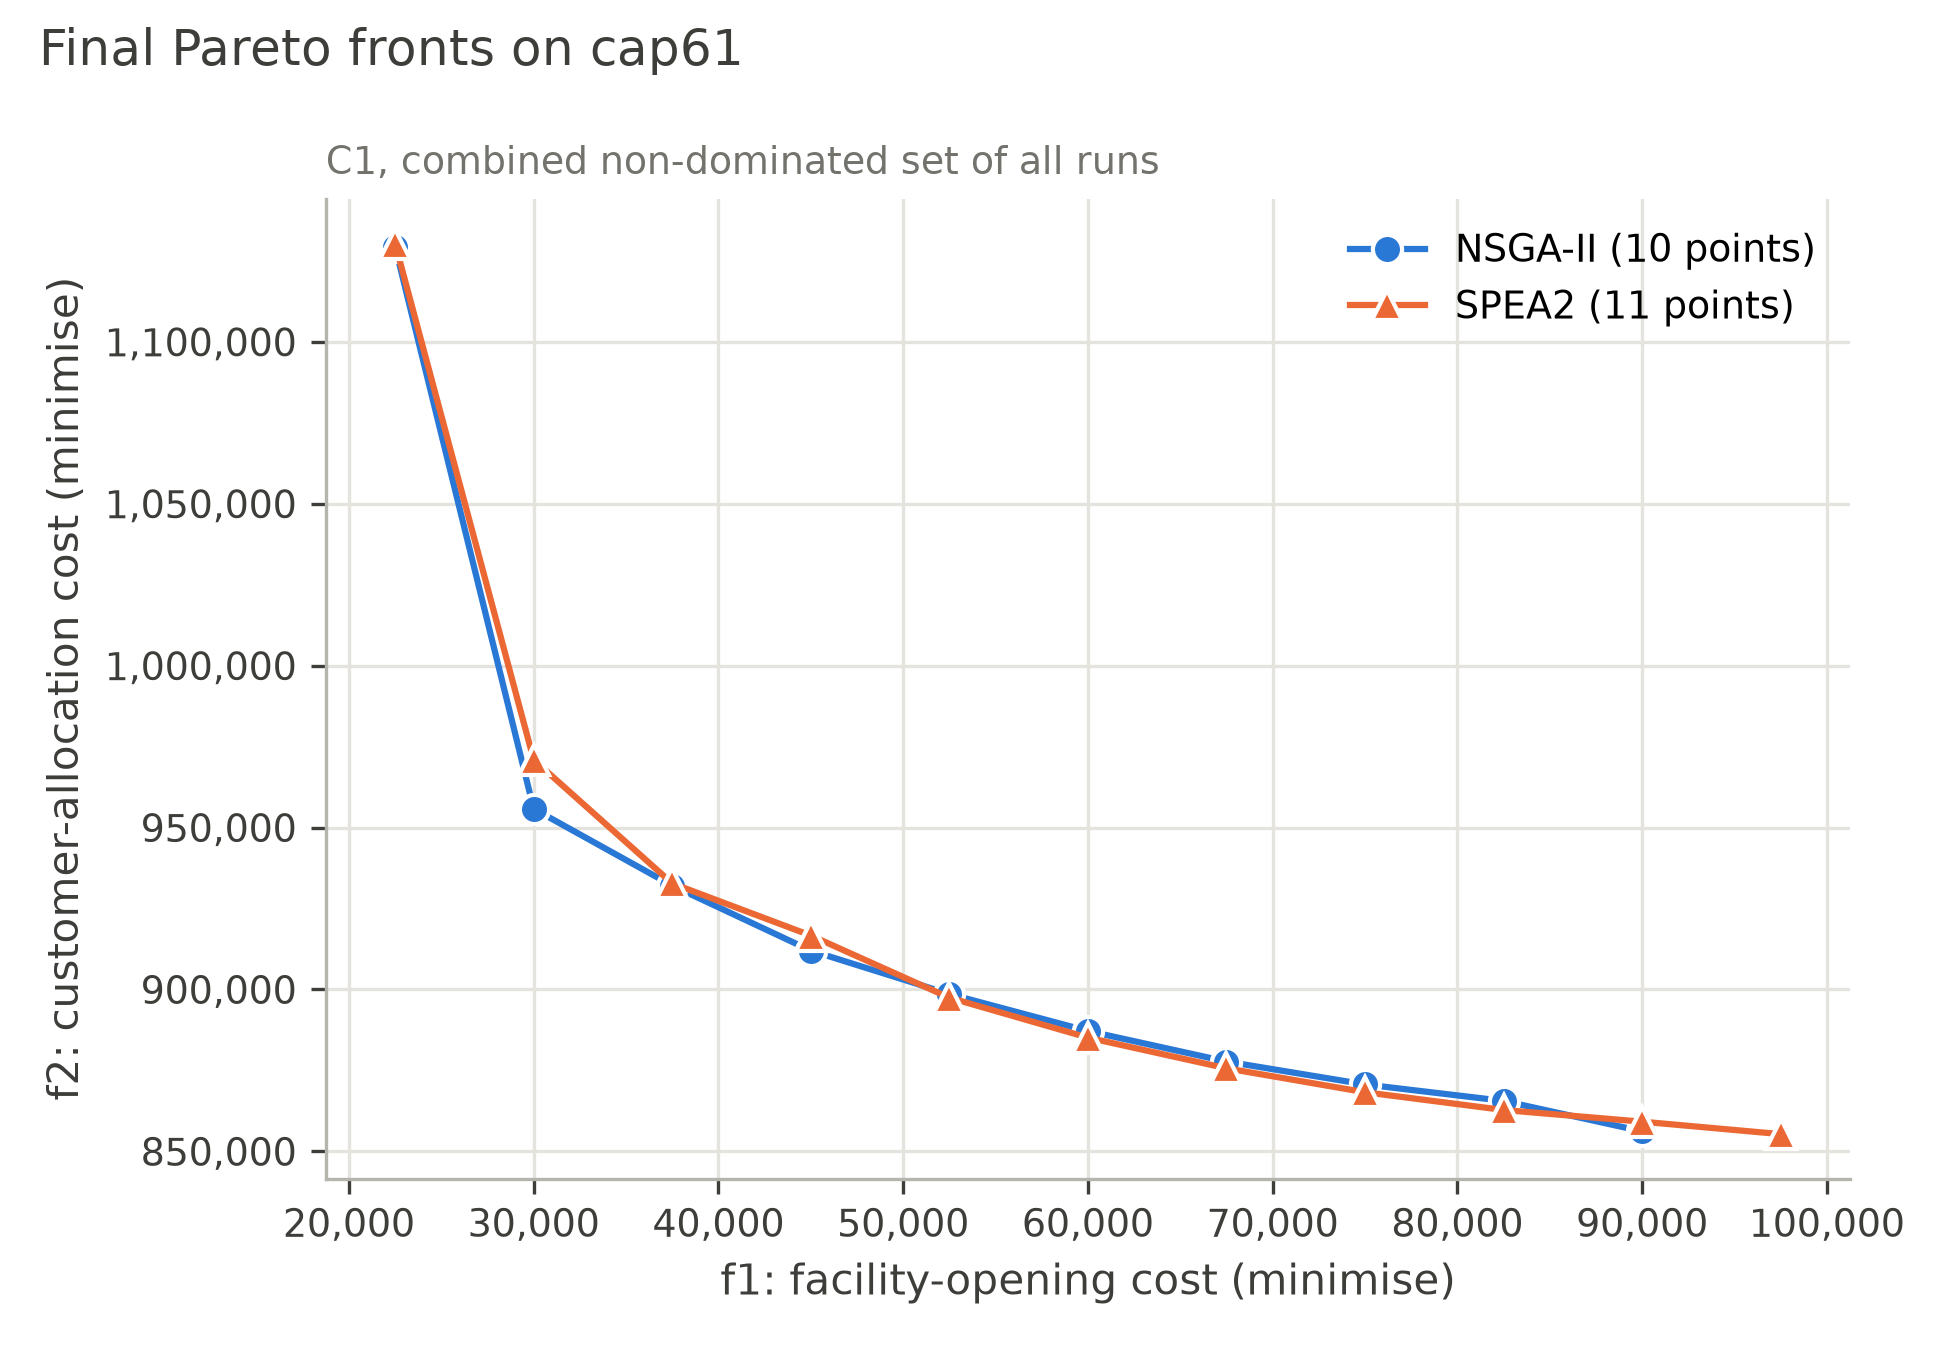

pareto_cap62.png


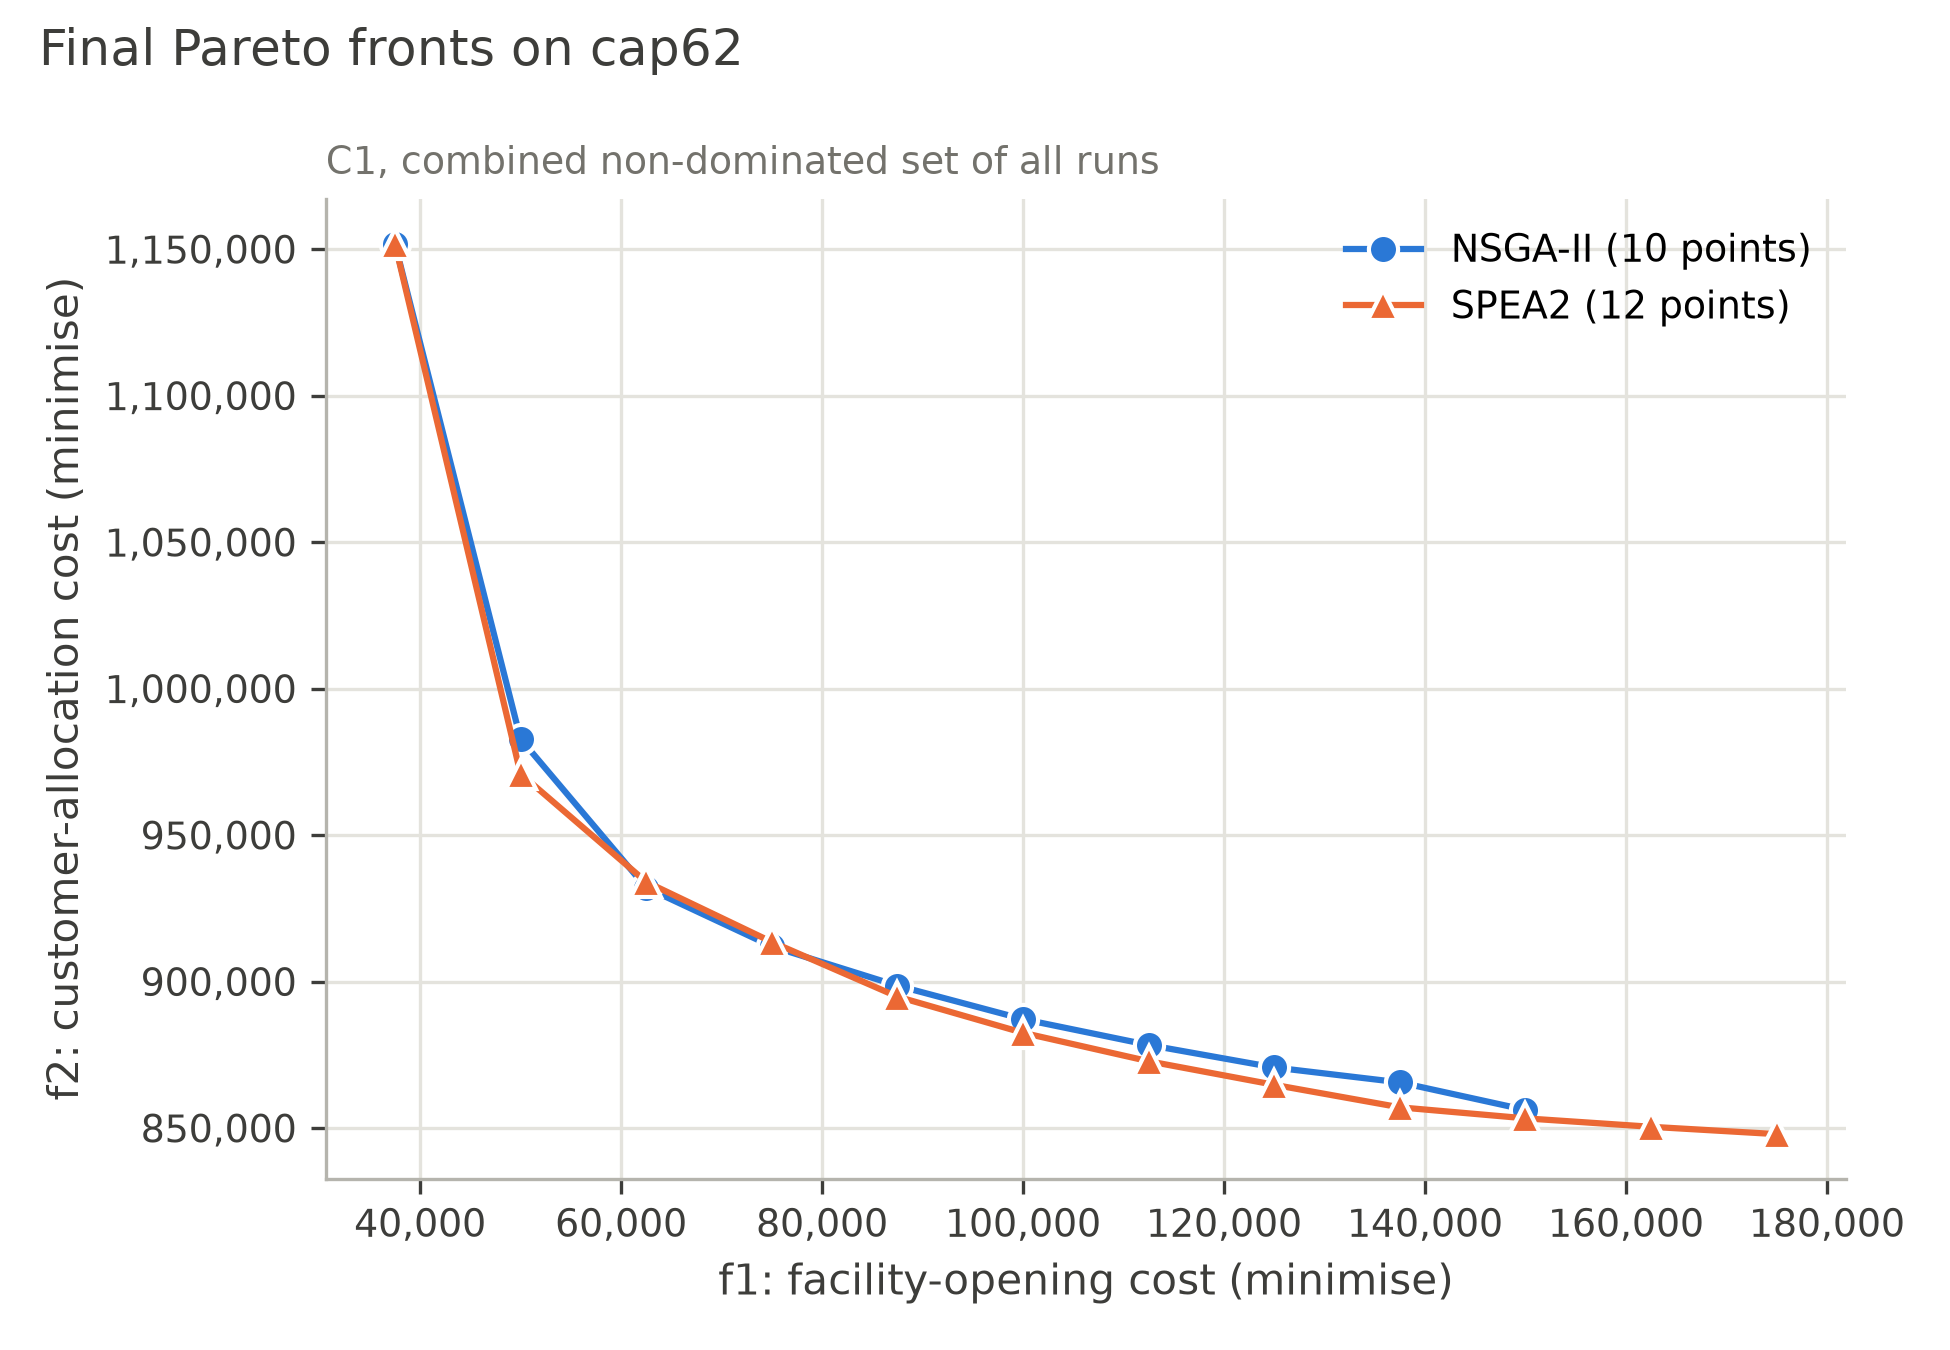

In [6]:
from IPython.display import Image, display
from src.util.fetch_config import FIGURES_DIR, TABLES_DIR

# One table and one Pareto-front plot per feasible instance
for path in sorted(TABLES_DIR.glob("results_*.png")) + sorted(FIGURES_DIR.glob("pareto_*.png")):
    print(path.name)
    display(Image(filename=path, width=800))